In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_useSVG = True

In [28]:
generated_full = pd.read_csv("../runs/antibiotics/staged_learning_1.csv")

In [29]:
print(f"Number generated: {len(generated_full):,}")
print(f"Number invalid = {len(generated_full[generated_full['SMILES_state'] == 0]):,}")

Number generated: 10,000
Number invalid = 135


In [30]:
generated = generated_full[generated_full["SMILES_state"] == 1]
print(f"Number generated after filtering invalid: {len(generated):,}")


Number generated after filtering invalid: 9,865


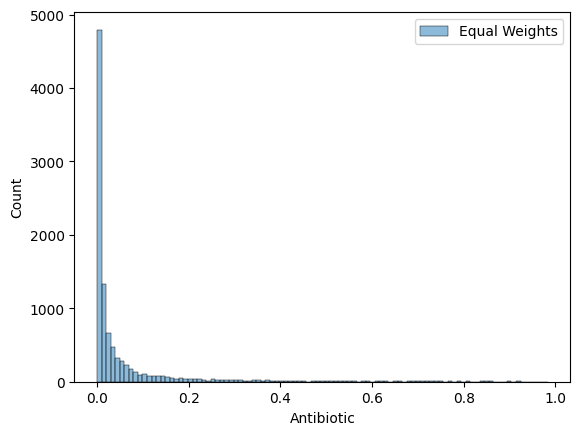

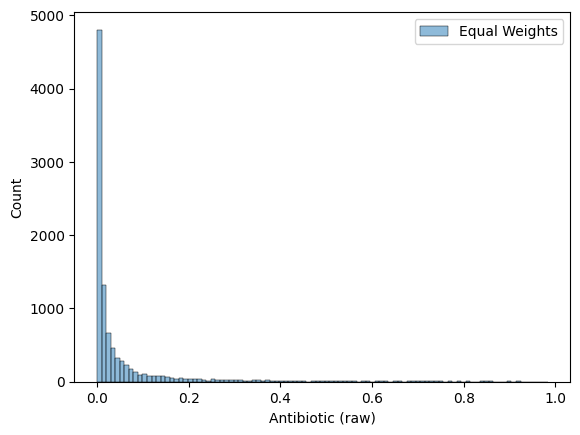

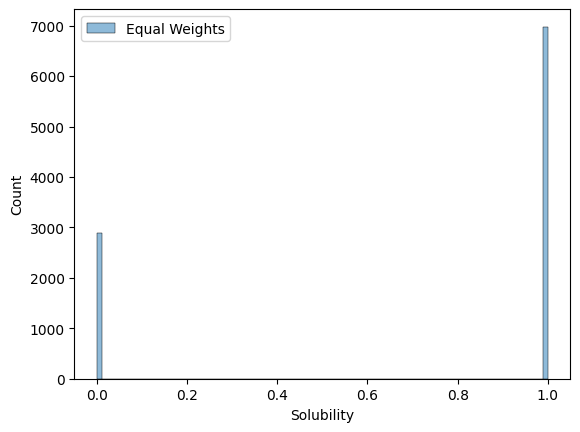

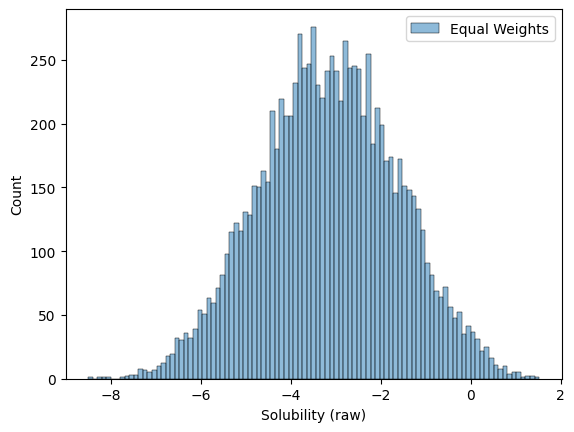

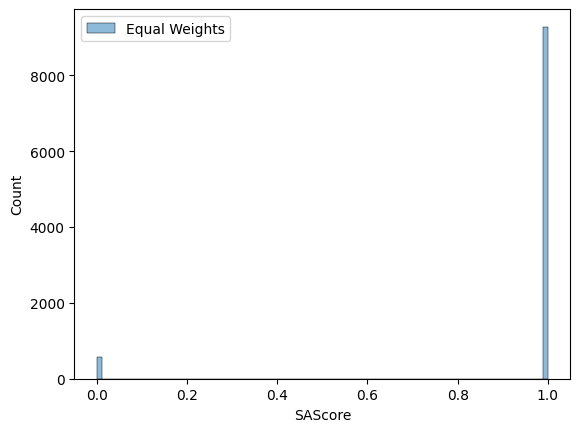

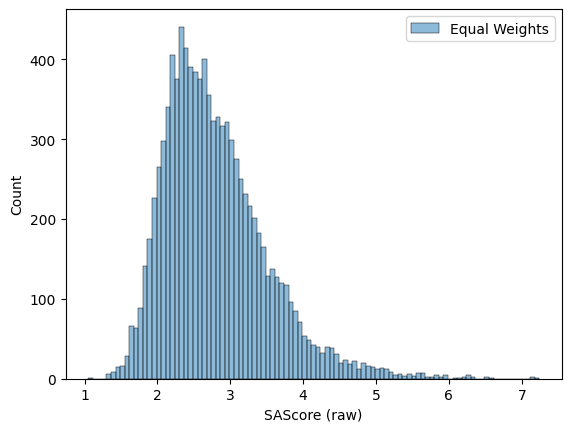

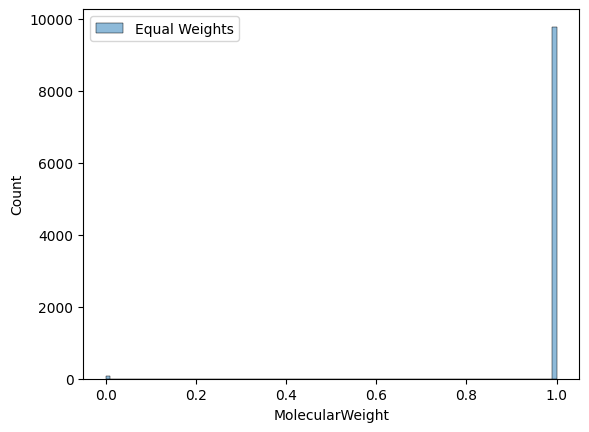

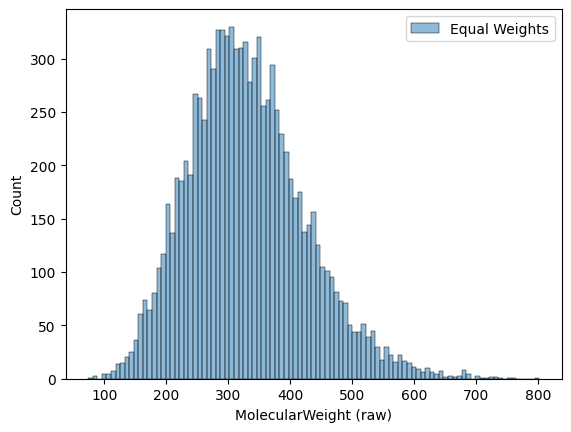

In [31]:
for prop in ["Antibiotic", "Solubility", "SAScore", "MolecularWeight"]:
    for suffix in ["", " (raw)"]:
        prop_name = prop + suffix

        min_val = generated[prop_name].min()
        max_val = generated[prop_name].max()
        bins = np.linspace(min_val, max_val, 100)

        sns.histplot(generated[prop_name], bins=bins, label="Equal Weights", alpha=0.5)
        plt.legend()
        plt.show()

In [32]:
hits = generated.query("`Antibiotic (raw)` > 0.5 & `Solubility (raw)` > -4 & `SAScore (raw)` <= 4 & `MolecularWeight (raw)` < 600")

print(f"Number of hits = {len(hits):,}")

Number of hits = 48


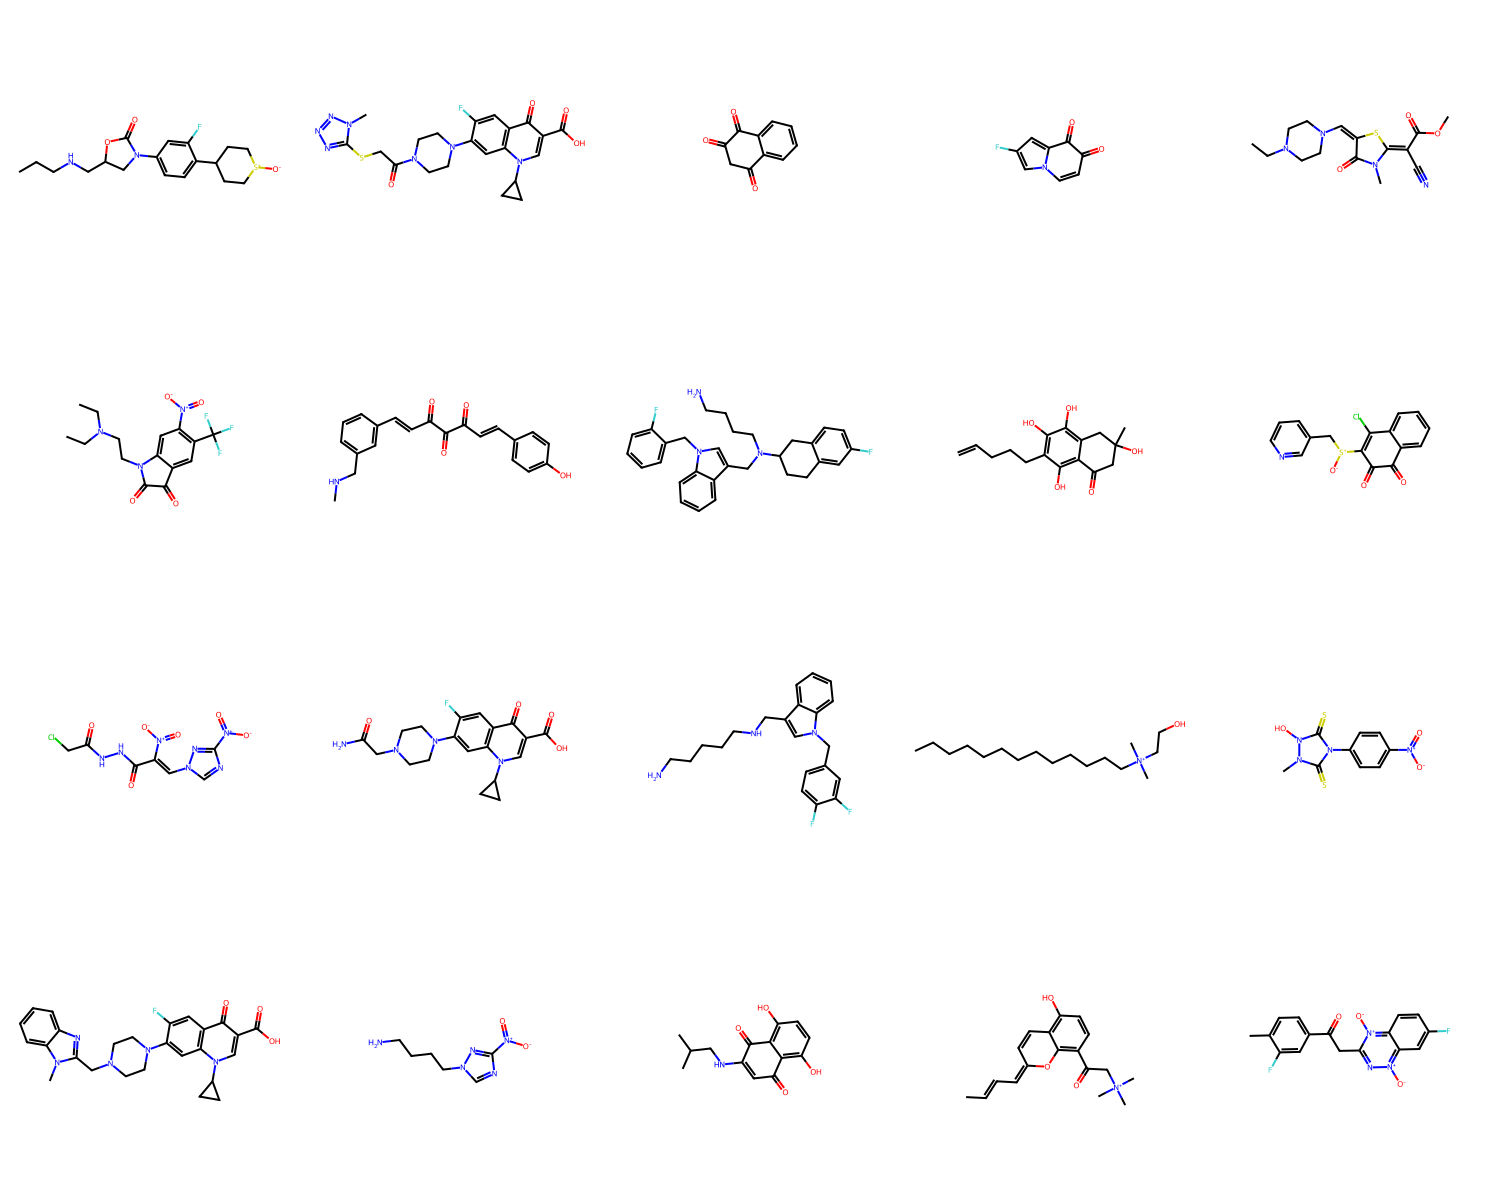

In [33]:
mols = [Chem.MolFromSmiles(smiles) for smiles in hits["SMILES"].sample(n=20, replace=False, random_state=0)]
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=5,
    subImgSize=(300, 300),
)
display(img)